In [7]:
import pandas as pd
DATA_PATH = "/content/drive/MyDrive/features_new.csv"
MODEL_DIR = "/content/drive/MyDrive/MODELS"


--- АНАЛІЗ ДАНИХ ---
Знайдено колонок: 65
Цільова змінна (Target): target_alarm_next_day
--------------------

--- Навчання та тюнінг (GridSearchCV): RandomForest ---
Модель RandomForest збережена як /content/drive/MyDrive/MODELSrandomforest_model.pkl


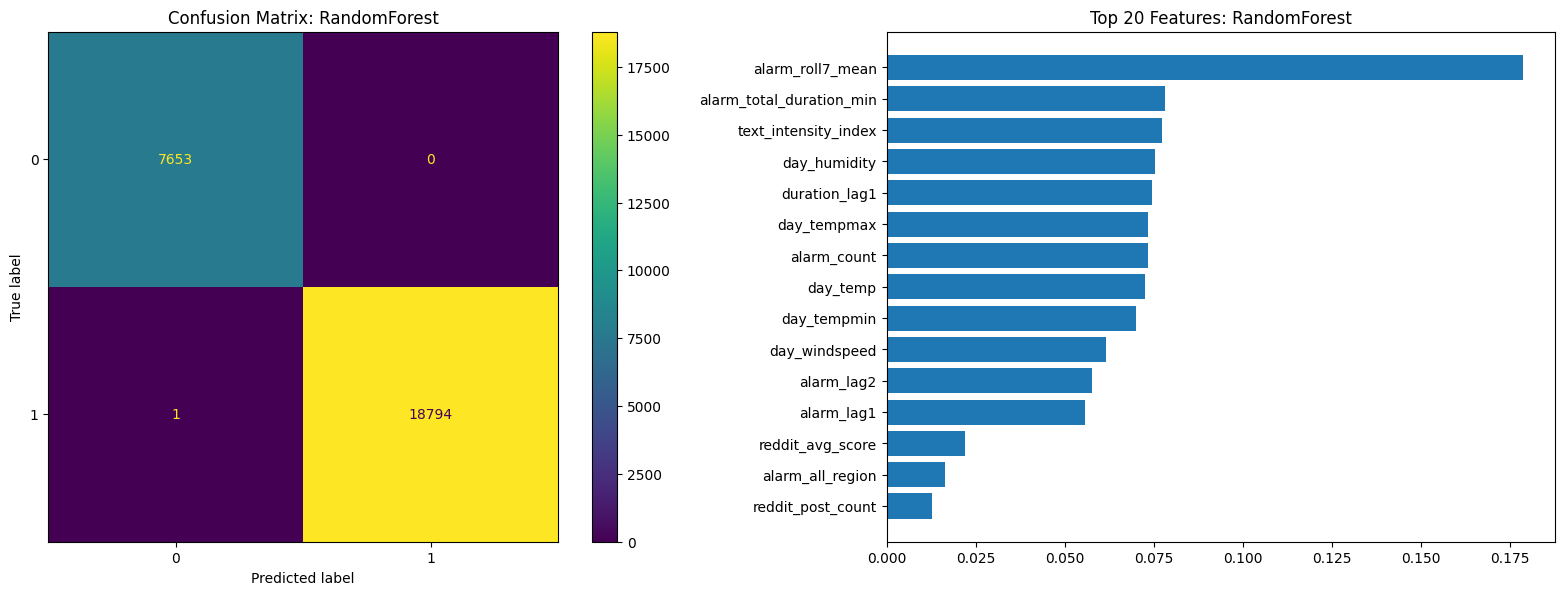

Найкращі параметри для RandomForest: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7653
           1       1.00      1.00      1.00     18795

    accuracy                           1.00     26448
   macro avg       1.00      1.00      1.00     26448
weighted avg       1.00      1.00      1.00     26448



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


os.makedirs(MODEL_DIR, exist_ok=True)

def train_and_evaluate():
    # Завантаження даних
    if not os.path.exists(DATA_PATH):
        print(f"Помилка: Файл {DATA_PATH} не знайдено!")
        return

    df = pd.read_csv(DATA_PATH)

    TARGET = 'target_alarm_next_day'
    print(f"\n--- АНАЛІЗ ДАНИХ ---")
    print(f"Знайдено колонок: {len(df.columns)}")
    print(f"Цільова змінна (Target): {TARGET}")
    print(f"--------------------\n")

    X = df.select_dtypes(include=[np.number]).drop(columns=[TARGET], errors='ignore').fillna(0)
    y = df[TARGET].astype(int)

    tscv = TimeSeriesSplit(n_splits=5)

    models_config = {
        "RandomForest": {
            "model": RandomForestClassifier(random_state=42),
            "params": {
                'n_estimators': [100, 200],
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5],
                'class_weight': ['balanced']
            }
        }
    }

    best_models = {}

    for name, config in models_config.items():
        print(f"--- Навчання та тюнінг (GridSearchCV): {name} ---")

        grid = GridSearchCV(
            config["model"],
            config["params"],
            cv=tscv,
            scoring='f1',
            n_jobs=-1
        )

        grid.fit(X, y)

        best_model = grid.best_estimator_
        best_models[name] = best_model

        # Збереження моделі
        model_filename = f"{MODEL_DIR}{name.lower()}_model.pkl"
        with open(model_filename, "wb") as f:
            pickle.dump(best_model, f)
        print(f"Модель {name} збережена як {model_filename}")

        # Прогноз
        y_pred = best_model.predict(X)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Confusion Matrix
        ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=ax1)
        ax1.set_title(f"Confusion Matrix: {name}")

        # Feature importance
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[-20:]

        ax2.barh(range(len(indices)), importances[indices])
        ax2.set_yticks(range(len(indices)))
        ax2.set_yticklabels([X.columns[i] for i in indices])
        ax2.set_title(f"Top 20 Features: {name}")

        plt.tight_layout()
        plt.show()

        print(f"Найкращі параметри для {name}: {grid.best_params_}")
        print(classification_report(y, y_pred))

if __name__ == "__main__":
    train_and_evaluate()